# Sprint 1 EDA — 데이터 파이프라인 검증

**목적**: `data/processed/returns.parquet` 및 `features.parquet` 검증 + 보고서 섹션 2 기초 자료  
**실행 전**: `python -m src.data.collector` 로 파일이 생성되어 있어야 한다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib import font_manager

KOREAN_FONT_CANDIDATES = ["AppleGothic", "NanumGothic", "Malgun Gothic", "Arial Unicode MS"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in KOREAN_FONT_CANDIDATES:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

RETURNS_PATH = Path("../data/processed/returns.parquet")
FEATURES_PATH = Path("../data/processed/features.parquet")

TICKERS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ", "069500", "114260"]

## 1. 파일 로드

In [2]:
returns = pd.read_parquet(RETURNS_PATH)
features = pd.read_parquet(FEATURES_PATH)

print("returns shape :", returns.shape)
print("features shape:", features.shape)

returns shape : (1898, 10)
features shape: (1865, 40)


## 2. 기본 정보 확인 (shape / columns / dtype / 날짜 범위)

In [3]:
print("=== returns ===")
print(f"index dtype : {returns.index.dtype}")
print(f"날짜 범위   : {returns.index[0].date()} ~ {returns.index[-1].date()}")
print(f"columns     : {list(returns.columns)}")
print()
print("=== features ===")
print(f"index dtype : {features.index.dtype}")
print(f"날짜 범위   : {features.index[0].date()} ~ {features.index[-1].date()}")
print(f"열 수       : {len(features.columns)}")
print(f"features 컬럼 (처음 8개): {list(features.columns[:8])}")

=== returns ===
index dtype : datetime64[ns]
날짜 범위   : 2018-01-03 ~ 2025-12-30
columns     : ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD', 'VNQ', '069500', '114260']

=== features ===
index dtype : datetime64[ns]
날짜 범위   : 2018-02-23 ~ 2025-12-30
열 수       : 40
features 컬럼 (처음 8개): ['SPY_return', 'QQQ_return', 'IWM_return', 'EFA_return', 'EEM_return', 'TLT_return', 'GLD_return', 'VNQ_return']


## 3. 결측치 확인

In [4]:
print("returns 결측치 합계  :", int(returns.isnull().sum().sum()))
print("features 결측치 합계 :", int(features.isnull().sum().sum()))

returns 결측치 합계  : 0
features 결측치 합계 : 0


## 4. returns 기술통계

In [5]:
returns.describe().round(4)

,SPY,QQQ,IWM,EFA,EEM,TLT,GLD,VNQ,069500,114260
count,1898.0000,1898.0000,1898.0000,1898.0000,1898.0000,1898.0000,1898.0000,1898.0000,1898.0000,1898.0000
mean,0.0006,0.0007,0.0003,0.0003,0.0002,-0.0001,0.0006,0.0002,0.0004,0.0001
std,0.0126,0.0154,0.0160,0.0116,0.0136,0.0101,0.0098,0.0145,0.0126,0.0014
min,-0.1159,-0.1276,-0.1423,-0.1164,-0.1333,-0.0690,-0.0664,-0.1951,-0.0963,-0.0098
25%,-0.0044,-0.0064,-0.0079,-0.0052,-0.0065,-0.0060,-0.0045,-0.0062,-0.0064,-0.0005
50%,0.0010,0.0015,0.0008,0.0008,0.0007,0.0003,0.0007,0.0007,0.0009,0.0001
75%,0.0066,0.0087,0.0093,0.0061,0.0075,0.0058,0.0057,0.0072,0.0076,0.0007
max,0.0999,0.1134,0.0875,0.0813,0.0775,0.0725,0.0474,0.0861,0.0888,0.0109


## 5. 자산별 로그수익률 분포

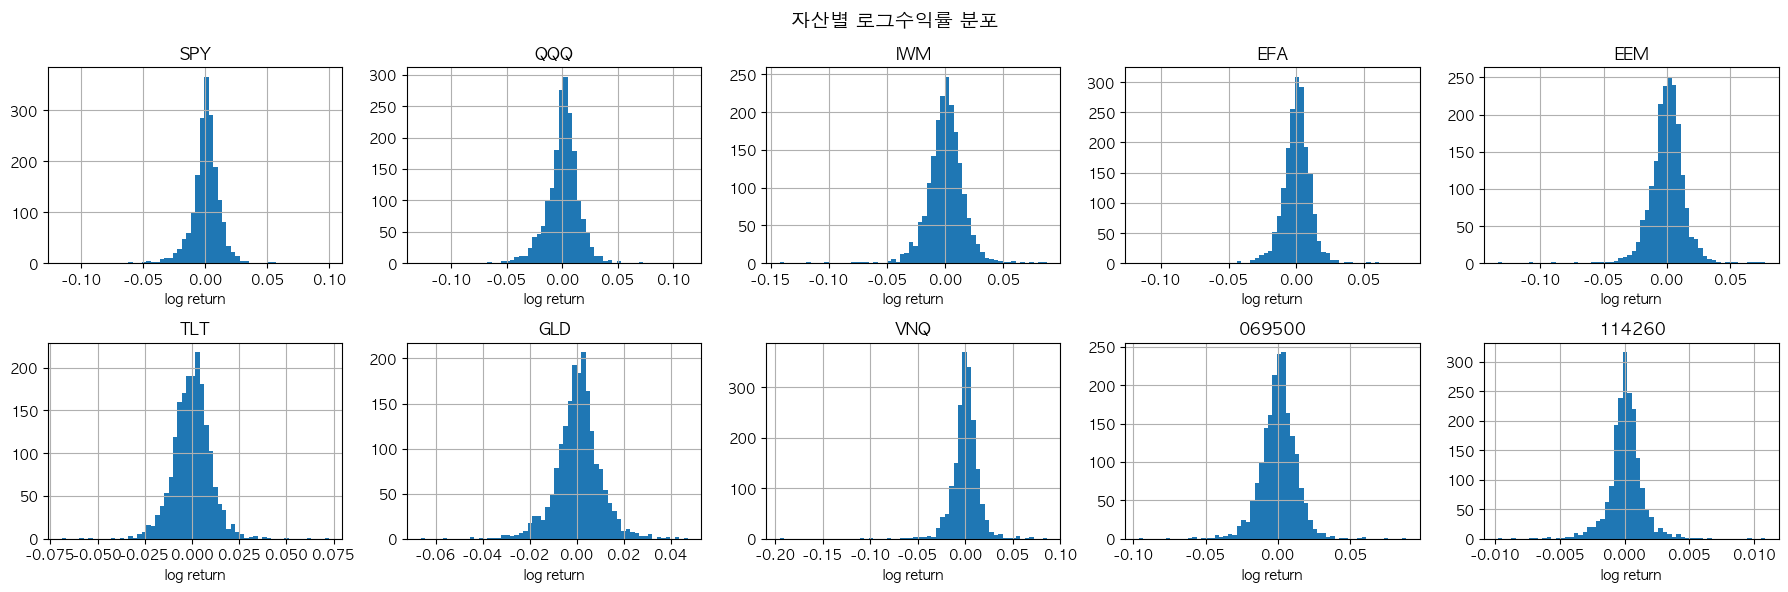

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    returns[ticker].hist(bins=60, ax=axes[i])
    axes[i].set_title(ticker)
    axes[i].set_xlabel("log return")

fig.suptitle("자산별 로그수익률 분포", fontsize=14)
plt.tight_layout()
plt.show()

## 6. 상관관계 히트맵

          SPY    QQQ    IWM    EFA    EEM    TLT    GLD    VNQ  069500  114260
SPY     1.000  0.936  0.868  0.859  0.761 -0.143  0.099  0.751   0.222  -0.012
QQQ     0.936  1.000  0.765  0.761  0.731 -0.090  0.106  0.603   0.186  -0.017
IWM     0.868  0.765  1.000  0.809  0.709 -0.114  0.102  0.758   0.204  -0.005
EFA     0.859  0.761  0.809  1.000  0.835 -0.105  0.219  0.710   0.286   0.008
EEM     0.761  0.731  0.709  0.835  1.000 -0.107  0.220  0.582   0.379  -0.040
TLT    -0.143 -0.090 -0.114 -0.105 -0.107  1.000  0.244  0.011  -0.070   0.148
GLD     0.099  0.106  0.102  0.219  0.220  0.244  1.000  0.144   0.061   0.065
VNQ     0.751  0.603  0.758  0.710  0.582  0.011  0.144  1.000   0.188   0.050
069500  0.222  0.186  0.204  0.286  0.379 -0.070  0.061  0.188   1.000   0.070
114260 -0.012 -0.017 -0.005  0.008 -0.040  0.148  0.065  0.050   0.070   1.000


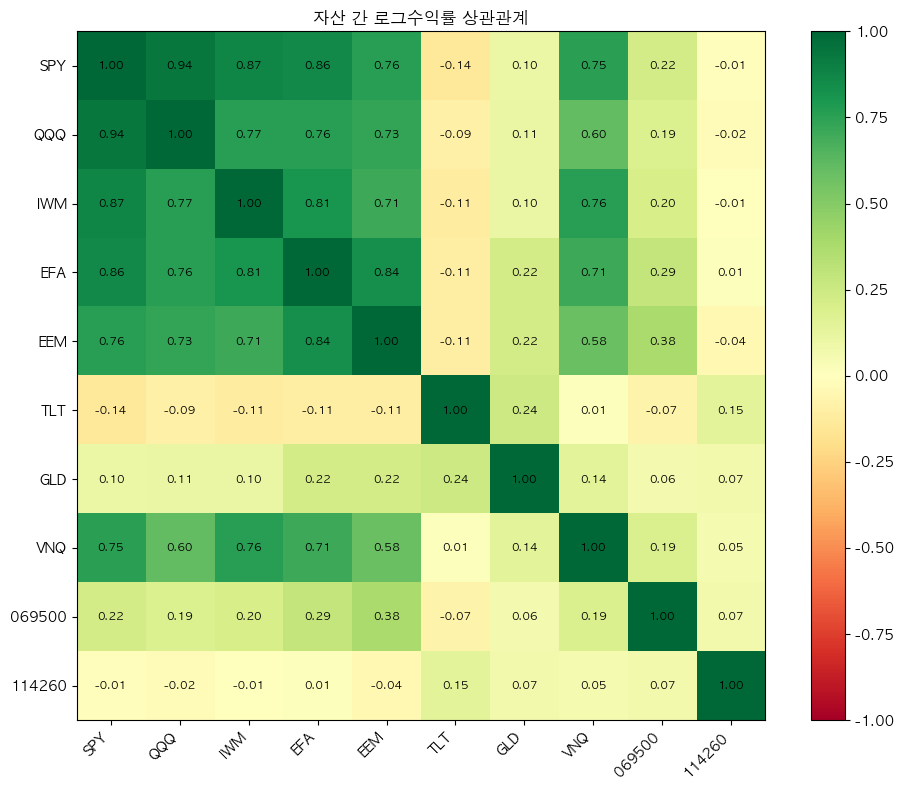

In [7]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS, rotation=45, ha="right")
ax.set_yticklabels(TICKERS)

for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("자산 간 로그수익률 상관관계")
plt.tight_layout()
plt.show()

print(corr.round(3))

## 7. 누적 수익률 그래프

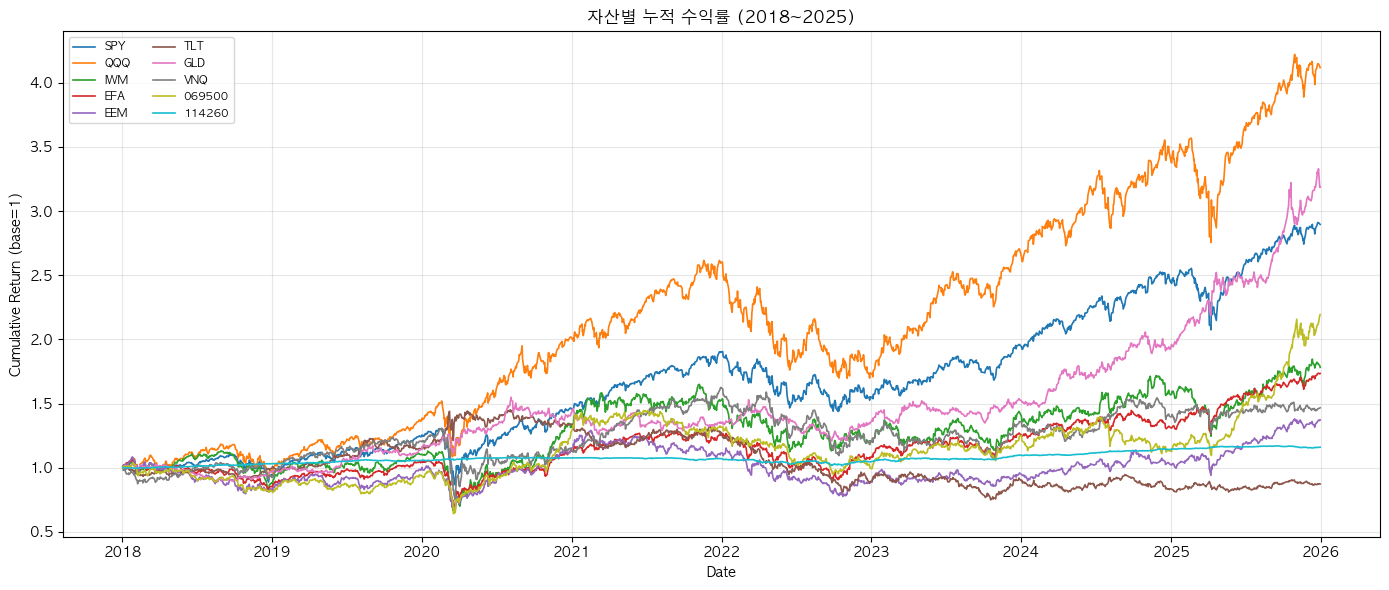

In [8]:
cumulative = returns.cumsum().apply(np.exp)  # log returns → price index

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in TICKERS:
    ax.plot(cumulative.index, cumulative[ticker], label=ticker, linewidth=1.2)

ax.set_title("자산별 누적 수익률 (2018~2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (base=1)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 자산별 변동성 비교 (연율화 표준편차)

IWM       0.2542
QQQ       0.2447
VNQ       0.2309
EEM       0.2153
069500    0.2007
SPY       0.1996
EFA       0.1847
TLT       0.1609
GLD       0.1558
114260    0.0219
dtype: float64


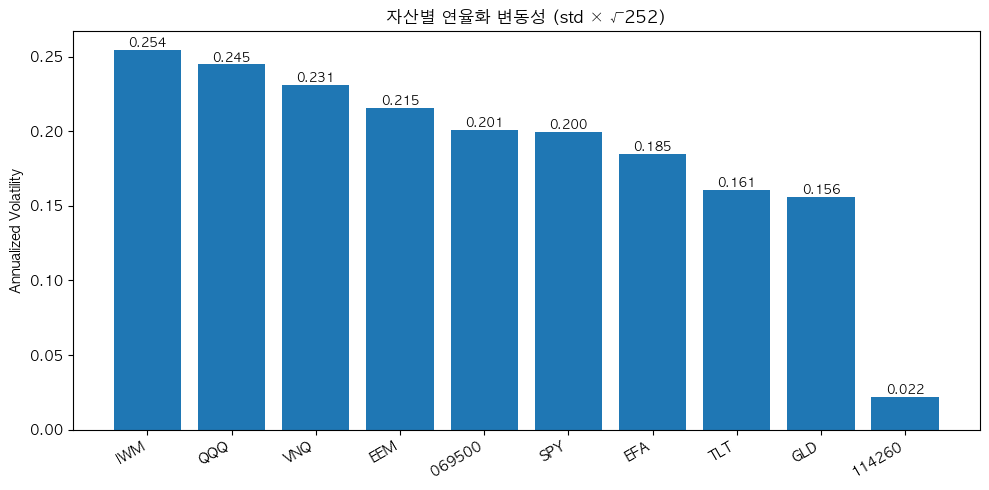

In [9]:
annual_vol = returns.std() * np.sqrt(252)
annual_vol_sorted = annual_vol.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(annual_vol_sorted.index, annual_vol_sorted.values)
ax.set_title("자산별 연율화 변동성 (std × √252)")
ax.set_ylabel("Annualized Volatility")
ax.set_xticks(range(len(annual_vol_sorted.index)))
ax.set_xticklabels(annual_vol_sorted.index, rotation=30, ha="right")
for i, v in enumerate(annual_vol_sorted.values):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(annual_vol_sorted.round(4))

## 9. features 컬럼 패턴 확인

In [10]:
return_cols = [c for c in features.columns if c.endswith("_return")]
rsi_cols    = [c for c in features.columns if c.endswith("_RSI")]
macd_cols   = [c for c in features.columns if c.endswith("_MACD")]
sig_cols    = [c for c in features.columns if c.endswith("_MACD_signal")]

print(f"_return 컬럼 수      : {len(return_cols)}")
print(f"_RSI 컬럼 수         : {len(rsi_cols)}")
print(f"_MACD 컬럼 수        : {len(macd_cols)}")
print(f"_MACD_signal 컬럼 수 : {len(sig_cols)}")
print(f"총 컬럼 수           : {len(features.columns)}")
print()
print("SPY 관련 컬럼 Z-score 통계:")
spy_cols = [c for c in features.columns if c.startswith("SPY")]
print(features[spy_cols].describe().round(3))

_return 컬럼 수      : 10
_RSI 컬럼 수         : 10
_MACD 컬럼 수        : 10
_MACD_signal 컬럼 수 : 10
총 컬럼 수           : 40

SPY 관련 컬럼 Z-score 통계:
       SPY_return   SPY_RSI  SPY_MACD  SPY_MACD_signal
count    1865.000  1865.000  1865.000         1865.000
mean        0.001     0.008     0.009           -0.000
std         0.999     0.984     0.987            1.000
min        -9.262    -5.263    -7.533           -5.554
25%        -0.397    -0.537    -0.439           -0.453
50%         0.028     0.022     0.046            0.034
75%         0.477     0.623     0.482            0.442
max         7.898     4.344     6.072            5.590
